<img src="http://drive.google.com/uc?export=view&id=1tpOCamr9aWz817atPnyXus8w5gJ3mIts" width=500px>

Proprietary content. © Great Learning. All Rights Reserved. Unauthorized use or distribution prohibited.

# Mobile Phone Review Analysis

## Context

The product companies can utilize the detailed review comments to gather insights from the end user. Most of the products are sold via e-commerce sites like Flipkart or Amazon where customers can buy a product and give their review about the product on the web site. 
Product managers can identify the relevant reviews from the website and run a sentiment analysis tool to understand what the sentiments of the customer are. Based on their sentiments, they can identify what users think of the current product. Are they happy? Discontent? 
They can also come up with a document that lists the features, the team needs to focus on for making the product better. 

## Objective

Given the review data rating label, we will try to get insights about various brands and their ratings using text analytics and build a model to predict the rating and overall sentiment. 


### Package version

- tensorflow==2.3.0
- scikit-learn==0.22.2.post1
- pandas==1.0.5
- numpy==1.18.5
- matplotlib==3.2.2
- google==2.0.3

### Data Dictionary 

product_data.csv - contains product details
- 'asin',  - Product ASIN
- 'brand', - Product Brand
- 'title', - Product Title
- 'url',  - Product URL
- 'image', - Product Image URL
- 'rating',- Product Avg. Rating
- 'reviewUrl' - Product Review Page URL
- 'totalReviews' - Product Total Reviews
- ‘price’ - Product Price ($)
- ‘originalPrice’ - Product Original Price ($)
 
reviews.csv  - contains user review details
 
- 'asin' - Product ASIN
- 'name' - Reviewer Name
- 'rating' - Reviewer Rating (scale 1 to 5)
- 'date'  - Review Date
- 'verified' - Valid Customer
- 'title'  - Review Title
- 'body'  - Review Content
- 'helpfulVotes  - Helpful Feedbacks


## Table of Content

1. Import Libraries

2. Setting options

3. Read Data

4. Data Analysis and EDA

5. Text preprocessing and Vectorization

6. Model building

7. Conclusion and Interpretation

## 1. Import Libraries

Let us start by mounting the drive

In [174]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Let us check for the version of installed tensorflow.

In [3]:
# used to supress display of warnings
import warnings

# os is used to provide a way of using operating system dependent functionality
# We use it for setting working folder
import os

# Pandas is used for data manipulation and analysis
import pandas as pd 

# Numpy is used for large, multi-dimensional arrays and matrices, along with mathematical operators on these arrays
import numpy as np

# Matplotlib is a data visualization library for 2D plots of arrays, built on NumPy arrays 
# and designed to work with the broader SciPy stack
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import pyplot

# Seaborn is based on matplotlib, which aids in drawing attractive and informative statistical graphics.
import seaborn as sns
import tensorflow 
print(tensorflow.__version__)

2.5.0


In [175]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/R8-Statistical NLP')

## 2. Setting Options

In [5]:
# suppress display of warnings
warnings.filterwarnings('ignore')

# display all dataframe columns
pd.options.display.max_columns = None

# to set the limit to 3 decimals
pd.options.display.float_format = '{:.7f}'.format

# display all dataframe rows
pd.options.display.max_rows = None

In [112]:
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob, Word
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet.zip.


True

In [172]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

## 3. Read Data

### 3.1 Read the provided CSVs and check 5 random samples and shape to understand the datasets

In [6]:
product_df=pd.read_csv("product_data.csv")
reviews_df=pd.read_csv("reviews.csv")

In [7]:
print(product_df.sample(5))
print("#"*20)
print(reviews_df.sample(5))

           asin     brand                                              title  \
37   B00A7F5M9W     Nokia     Nokia Lumia 822, White 16GB (Verizon Wireless)   
649  B07VGTHTGN   Samsung  Samsung Galaxy A70 128GB/6GB SM-A705MN/DS 6.7"...   
627  B07SVFGKCJ   Samsung  Samsung Galaxy S10+ Plus Verizon + GSM Unlocke...   
429  B07GGGTT78  Motorola  Motorola Moto G4 Plus XT1642 4G LTE Dual SIM F...   
336  B0788ZD69Z   Samsung  Samsung Galaxy S8 Plus Unlocked 64GB (Midnight...   

                                                   url  \
37   https://www.amazon.com/Nokia-Lumia-822-Verizon...   
649  https://www.amazon.com/Samsung-SM-A705MN-Infin...   
627  https://www.amazon.com/Samsung-Galaxy-Verizon-...   
429  https://www.amazon.com/Motorola-Moto-G4-Plus-U...   
336  https://www.amazon.com/Samsung-Galaxy-S8-Plus-...   

                                                 image    rating  \
37   https://m.media-amazon.com/images/I/81OtSgABAY... 3.6000000   
649  https://m.media-amazon.com/im

In [8]:
product_df.sample(5)

,asin,brand,title,url,image,rating,reviewUrl,totalReviews,price,originalPrice
657,B07W14HFQP,Motorola,Motorola Moto G4 Play (4th Generation) 16GB 4G...,https://www.amazon.com/Motorola-Generation-Unl...,https://m.media-amazon.com/images/I/61ktS3pR0T...,3.6000000,https://www.amazon.com/product-reviews/B07W14HFQP,133,129.0000000,0.0000000
628,B07SVFJ3P5,Samsung,Samsung Galaxy S10+ Plus Verizon + GSM Unlocke...,https://www.amazon.com/Samsung-Galaxy-Verizon-...,https://m.media-amazon.com/images/I/51oYKiSb5T...,1.5000000,https://www.amazon.com/product-reviews/B07SVFJ3P5,5,539.9900000,0.0000000
16,B004C7NVD0,Samsung,Samsung Convoy SCH-U640 Cell Phone Ruggedized ...,https://www.amazon.com/Samsung-SCH-U640-Rugged...,https://m.media-amazon.com/images/I/61ve0RjDSU...,3.2000000,https://www.amazon.com/product-reviews/B004C7NVD0,107,199.9900000,0.0000000
21,B005B3OXWC,Samsung,Samsung Freeform III Prepaid Phone (MetroPCS),https://www.amazon.com/Samsung-Freeform-Prepai...,https://m.media-amazon.com/images/I/81l1bw5bs7...,3.1000000,https://www.amazon.com/product-reviews/B005B3OXWC,32,0.0000000,0.0000000
376,B07BHT4KGM,Samsung,"Samsung Galaxy S9 Sm-G9600 Dual Sim 5.8"" Super...",https://www.amazon.com/Samsung-Galaxy-SM-G9600...,https://m.media-amazon.com/images/I/71uI+nAzru...,3.9000000,https://www.amazon.com/product-reviews/B07BHT4KGM,95,503.0900000,0.0000000


In [9]:
reviews_df.sample(5)

,asin,name,rating,date,verified,title,body,helpfulVotes
31325,B06XRG6S73,Hannah,5,"May 8, 2019",True,Worth it!,Yes I was paranoid when I was looking through ...,nan
3027,B00836Y6B2,Thommasson,5,"June 22, 2013",True,Great unlocked phone,The phone is amazing. It is SIM free and the s...,nan
14884,B00OZTSY6Y,Amazon Customer,3,"September 15, 2016",True,Love it but it's fragile,"I am in LOVE with this phone, but after having...",nan
19219,B018OMP8ES,Andres,5,"August 1, 2019",True,Bueno buen vendedor excelente,Excelente bueno,nan
2108,B007X6FFLS,jessica calley,4,"May 15, 2013",True,GoPhone,"Although I am a smart phone kind of person, I ...",nan


In [10]:
product_df.shape

(720, 10)

In [11]:
reviews_df.shape

(67986, 8)

## 4.  Data Analysis and EDA

### 4.1 Drop unnecessary columns like 'url', 'image' from the product_data

In [12]:
print(product_df.columns)
print(reviews_df.columns)

Index(['asin', 'brand', 'title', 'url', 'image', 'rating', 'reviewUrl',
       'totalReviews', 'price', 'originalPrice'],
      dtype='object')
Index(['asin', 'name', 'rating', 'date', 'verified', 'title', 'body',
       'helpfulVotes'],
      dtype='object')


In [13]:
col=['url', 'image', 'reviewUrl']
product_df.drop(col, inplace=True, axis=1)

### 4.2 Check statistical summary of both datasets. Note:- Include both numerical and object type columns.

In [14]:
product_df.describe(include='all')

,asin,brand,title,rating,totalReviews,price,originalPrice
count,720,716,720,720.0000000,720.0000000,720.0000000,720.0000000
unique,720,10,718,nan,nan,nan,nan
top,B01N5WQ2P4,Samsung,"Apple iPhone 6S, 64GB, Rose Gold - For AT&T / ...",nan,nan,nan,nan
freq,1,346,2,nan,nan,nan,nan
mean,NaN,NaN,NaN,3.7137500,105.6791667,234.9489306,63.6907778
std,NaN,NaN,NaN,0.7160138,167.6011014,200.0084407,172.4053696
min,NaN,NaN,NaN,1.0000000,1.0000000,0.0000000,0.0000000
25%,NaN,NaN,NaN,3.3000000,7.0000000,97.5125000,0.0000000
50%,NaN,NaN,NaN,3.8000000,32.0000000,188.9750000,0.0000000
75%,NaN,NaN,NaN,4.1000000,122.2500000,336.7250000,0.0000000


In [15]:
reviews_df.describe(include='all')

,asin,name,rating,date,verified,title,body,helpfulVotes
count,67986,67984,67986.0000000,67986,67986,67972,67965,27215.0000000
unique,720,47323,nan,2983,2,41489,59811,nan
top,B00F2SKPIM,Amazon Customer,nan,"December 11, 2019",True,Five Stars,Good,nan
freq,981,6507,nan,234,61225,6043,303,nan
mean,NaN,NaN,3.8079163,NaN,NaN,NaN,NaN,8.2296895
std,NaN,NaN,1.5829058,NaN,NaN,NaN,NaN,31.9548772
min,NaN,NaN,1.0000000,NaN,NaN,NaN,NaN,1.0000000
25%,NaN,NaN,3.0000000,NaN,NaN,NaN,NaN,1.0000000
50%,NaN,NaN,5.0000000,NaN,NaN,NaN,NaN,2.0000000
75%,NaN,NaN,5.0000000,NaN,NaN,NaN,NaN,5.0000000


### 4.3 From the above statistical summary, write inferences like count of unique products, top brand, top title, range of rating, price range, etc

In [16]:
product_df.nunique()

asin             720
brand             10
title            718
rating            33
totalReviews     247
price            453
originalPrice     90
dtype: int64

In [17]:
product_df.isna().sum()

asin             0
brand            4
title            0
rating           0
totalReviews     0
price            0
originalPrice    0
dtype: int64

In [18]:
product_df['brand'].value_counts()

Samsung     346
Motorola    105
Apple        63
Xiaomi       46
Nokia        44
Google       38
HUAWEI       32
Sony         27
OnePlus      10
ASUS          5
Name: brand, dtype: int64

In [19]:
# counting unique values
n = len(pd.unique(product_df['asin']))
  
print("No.of.unique values :", 
      n)

No.of.unique values : 720


In [20]:
# 720 unique products
# 10 unqiue phone brands
# 4 missing value in brands.
# Ratings ranges from 1 to 5
# Mean ratings for products are 3.713
# Price ranges from 0 to 999
# Top brand - 'Amazon Customer'
# Top title - 'Apple iPhone 6S, 64GB, Rose Gold'

### 4.4 Analyze the distribution of ratings and other categorical features like brand, etc

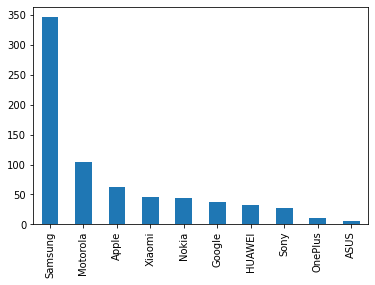

In [21]:
product_df['brand'].value_counts().plot( kind = 'bar')

In [22]:
product_df['brand'].value_counts()/len(product_df)* 100

Samsung    48.0555556
Motorola   14.5833333
Apple       8.7500000
Xiaomi      6.3888889
Nokia       6.1111111
Google      5.2777778
HUAWEI      4.4444444
Sony        3.7500000
OnePlus     1.3888889
ASUS        0.6944444
Name: brand, dtype: float64

In [23]:
product_df[product_df['price'] == 0]

,asin,brand,title,rating,totalReviews,price,originalPrice
0,B0000SX2UC,NaN,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,3.0000000,14,0.0000000,0.0000000
3,B001AO4OUC,Motorola,Motorola i335 Cell Phone Boost Mobile,3.3000000,21,0.0000000,0.0000000
5,B001GQ3DJM,Nokia,Nokia 1680 Black Phone (T-Mobile),2.7000000,3,0.0000000,0.0000000
6,B0029F2O3A,Samsung,"Samsung Alias2 U750 Phone, Black (Verizon Wire...",3.0000000,29,0.0000000,0.0000000
7,B002AS9WEA,Samsung,Samsung a167 Prepaid GoPhone (AT&T),2.9000000,18,0.0000000,0.0000000
8,B002UHS0UI,Motorola,Verizon Wireless Motorola RAZR V3m - Silver,2.7000000,208,0.0000000,0.0000000
18,B004H23JXW,Samsung,Samsung Focus I917 Unlocked Phone with Windows...,3.4000000,349,0.0000000,0.0000000
19,B004MK9VLS,Nokia,Nokia C3 Prepaid GoPhone (AT&T) with $30 Airti...,3.0000000,7,0.0000000,0.0000000
20,B004YBP8EY,Samsung,Samsung SA-S5260WESP Cellphone - Unlocked Phon...,3.1000000,23,0.0000000,0.0000000
21,B005B3OXWC,Samsung,Samsung Freeform III Prepaid Phone (MetroPCS),3.1000000,32,0.0000000,0.0000000


### 4.5 Display average rating per brand

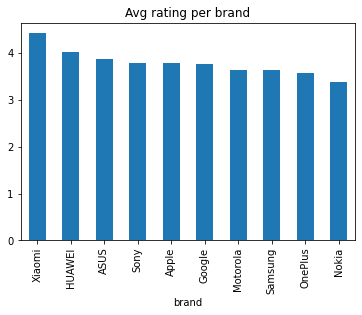

In [24]:
product_df.groupby('brand')['rating'].mean().sort_values(ascending=False).plot(kind='bar', title='Avg rating per brand')

### 4.6 Display average price per brand

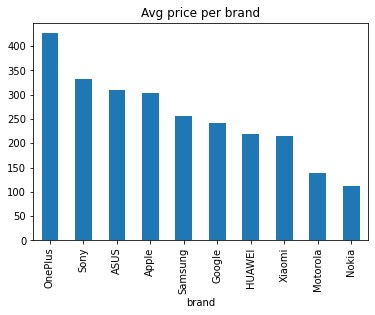

In [25]:
product_df.groupby('brand')['price'].mean().sort_values(ascending=False).plot(kind='bar', title='Avg price per brand')

### 4.7 Display average 'totalReviews' per brand

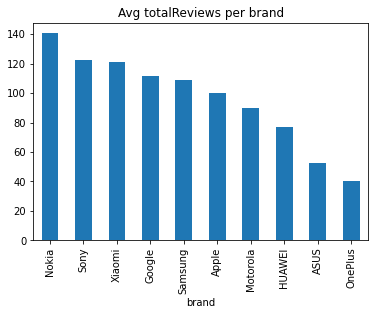

In [26]:
product_df.groupby('brand')['totalReviews'].mean().sort_values(ascending=False).plot(kind='bar', title='Avg totalReviews per brand')

### 4.8 Merge two datasets using 'asin' and check the shape of the final dataset

In [27]:
final_df=pd.merge(reviews_df, product_df, how='left',  left_on='asin', right_on='asin')

In [28]:
final_df.shape

(67986, 14)

In [29]:
final_df.sample(2)

,asin,name,rating_x,date,verified,title_x,body,helpfulVotes,brand,title_y,rating_y,totalReviews,price,originalPrice
48757,B07D6TQP6F,Mariant Noguera,5,"April 4, 2019",True,..,Excellent product,nan,Apple,"Apple iPhone X, 256GB, Silver - For AT&T (Rene...",3.9000000,436,476.0000000,0.0000000
14797,B00OZTSY6Y,David M,5,"September 26, 2018",True,Good value,Great phone works great,nan,Motorola,"Motorola DROID Turbo XT1254, Black Ballistic N...",3.6000000,545,149.9900000,0.0000000


In [30]:
final_df.columns

Index(['asin', 'name', 'rating_x', 'date', 'verified', 'title_x', 'body',
       'helpfulVotes', 'brand', 'title_y', 'rating_y', 'totalReviews', 'price',
       'originalPrice'],
      dtype='object')

### 4.9 Rename important features with appropriate names.
Imortant features - "rating_x": "user_rating", "title_x": "review_title", "title_y": "item_title", "rating_y": "overall_rating"

In [31]:
final_df=final_df.rename(columns={"rating_x": "user_rating", "title_x": "review_title", "title_y": "item_title", "rating_y": "overall_rating"})

In [32]:
final_df.columns

Index(['asin', 'name', 'user_rating', 'date', 'verified', 'review_title',
       'body', 'helpfulVotes', 'brand', 'item_title', 'overall_rating',
       'totalReviews', 'price', 'originalPrice'],
      dtype='object')

In [33]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 67986 entries, 0 to 67985
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   asin            67986 non-null  object 
 1   name            67984 non-null  object 
 2   user_rating     67986 non-null  int64  
 3   date            67986 non-null  object 
 4   verified        67986 non-null  bool   
 5   review_title    67972 non-null  object 
 6   body            67965 non-null  object 
 7   helpfulVotes    27215 non-null  float64
 8   brand           67786 non-null  object 
 9   item_title      67986 non-null  object 
 10  overall_rating  67986 non-null  float64
 11  totalReviews    67986 non-null  int64  
 12  price           67986 non-null  float64
 13  originalPrice   67986 non-null  float64
dtypes: bool(1), float64(4), int64(2), object(7)
memory usage: 7.3+ MB


### 4.10 Select rows having verified reviews and check the shape of the final dataset

In [34]:
final_df['verified'].value_counts()

True     61225
False     6761
Name: verified, dtype: int64

In [35]:
df=final_df[final_df['verified']== True]

In [36]:
df.head()

,asin,name,user_rating,date,verified,review_title,body,helpfulVotes,brand,item_title,overall_rating,totalReviews,price,originalPrice
14,B0009N5L7K,Marcel Thomas,1,"March 5, 2016",True,Stupid phone,DON'T BUY OUT OF SERVICE,nan,Motorola,Motorola I265 phone,3.0000000,7,49.9500000,0.0000000
17,B0009N5L7K,Stephen Cahill,1,"December 20, 2016",True,Phones locked,1 star because the phones locked so I have to ...,nan,Motorola,Motorola I265 phone,3.0000000,7,49.9500000,0.0000000
18,B0009N5L7K,Mihir,5,"December 13, 2009",True,Excellent product,The product has been very good. I had used thi...,nan,Motorola,Motorola I265 phone,3.0000000,7,49.9500000,0.0000000
21,B000SKTZ0S,Thomas,4,"September 17, 2010",True,"Nice, but",I bought this phone to replace an LG phone tha...,nan,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,2.7000000,22,99.9900000,0.0000000
22,B000SKTZ0S,"Kei, San Jose, CA",1,"May 13, 2017",True,It seems it doesn't work with the existing AT&...,I purchased this phone for my AT&T phone repla...,nan,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,2.7000000,22,99.9900000,0.0000000


### 4.11 Check the number of reviews for various brands and report the brand that have highest number of reviews

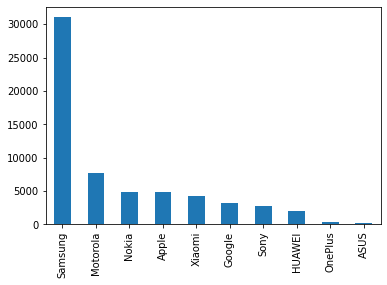

In [37]:
df['brand'].value_counts().plot(kind='bar')

Inference: Samsung brand has the highest number of reviews and followed by Motorola, Nokia, Apple.

### 4.12 Drop irrelevant columns and keep important features like 'brand','body','price','user_rating','review_title' for further analysis

In [72]:
df.columns

Index(['asin', 'name', 'user_rating', 'date', 'verified', 'review_title',
       'body', 'helpfulVotes', 'brand', 'item_title', 'overall_rating',
       'totalReviews', 'price', 'originalPrice'],
      dtype='object')

In [73]:
col=['brand','body','price','user_rating','review_title']
df_review=df[col]
df_review.head()

,brand,body,price,user_rating,review_title
14,Motorola,DON'T BUY OUT OF SERVICE,49.9500000,1,Stupid phone
17,Motorola,1 star because the phones locked so I have to ...,49.9500000,1,Phones locked
18,Motorola,The product has been very good. I had used thi...,49.9500000,5,Excellent product
21,Motorola,I bought this phone to replace an LG phone tha...,99.9900000,4,"Nice, but"
22,Motorola,I purchased this phone for my AT&T phone repla...,99.9900000,1,It seems it doesn't work with the existing AT&...


### 4.13 Perform univariate analysis. Check distribution of price, user_rating

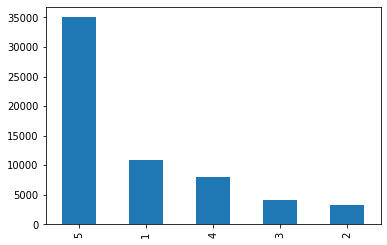

In [74]:
df_review['user_rating'].value_counts().plot(kind='bar')

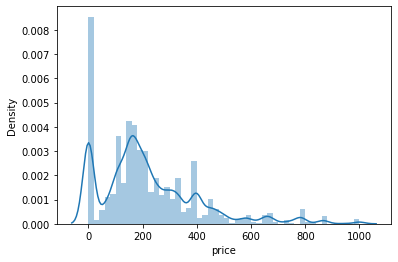

In [75]:
sns.distplot(df_review['price'])

### 4.14 Create a new column called "sentiment". It should have value as 1 (positive) if the user_Rating is greater than 3, value as 0 (neutral) if the user_Rating == 3, and -1 (negative) is the user_Rating is less than 3.

In [76]:
df_review["sentiment"]=df_review['user_rating'].apply(lambda x: 1 if x > 3 else (0 if x == 3 else -1))
df_review.head()

,brand,body,price,user_rating,review_title,sentiment
14,Motorola,DON'T BUY OUT OF SERVICE,49.9500000,1,Stupid phone,-1
17,Motorola,1 star because the phones locked so I have to ...,49.9500000,1,Phones locked,-1
18,Motorola,The product has been very good. I had used thi...,49.9500000,5,Excellent product,1
21,Motorola,I bought this phone to replace an LG phone tha...,99.9900000,4,"Nice, but",1
22,Motorola,I purchased this phone for my AT&T phone repla...,99.9900000,1,It seems it doesn't work with the existing AT&...,-1


### 4.15 Check frequency distribution of the 'sentiment'

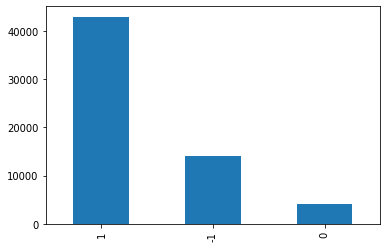

In [77]:
df_review['sentiment'].value_counts().plot(kind='bar')

### 4.16 Perform bivariate analysis. Check correlation/crosstab between features and write your inferences.

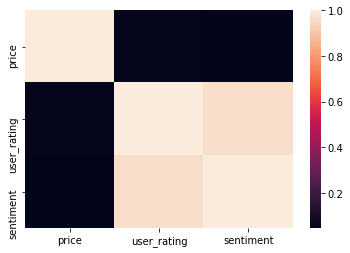

In [47]:
sns.heatmap(df_review.corr())

In [78]:
pd.crosstab(df_review['brand'], df_review['sentiment'])

sentiment,-1,0,1
brand,,,
ASUS,49,20,137
Apple,1320,307,3249
Google,804,207,2152
HUAWEI,261,105,1653
Motorola,1667,553,5494
Nokia,1437,467,2974
OnePlus,34,11,259
Samsung,7469,2030,21521
Sony,663,216,1812


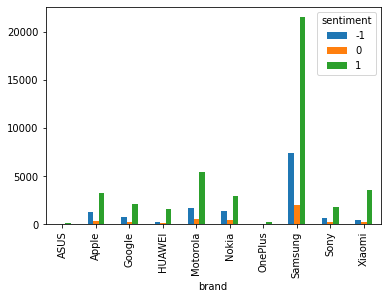

In [50]:
pd.crosstab(df_review['brand'], df_review['sentiment']).plot(kind='bar')

## 5. Text Preprocessing and Vectorization

We will analyze the 'body' and 'review_title' to gain more understanding.

We will ppeform the below tasks

- Convert the text into lowercase
- Remove punctuation
- Remove stopwords (English, from nltk corpus)
- Remove other keywords like "phone" and brand name

### 5.1 Change the datatype of the 'body' column to 'str' and convert it into lowercase. Print any two samples and check the output.

In [79]:
df_review.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 61225 entries, 14 to 67984
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         61078 non-null  object 
 1   body          61207 non-null  object 
 2   price         61225 non-null  float64
 3   user_rating   61225 non-null  int64  
 4   review_title  61211 non-null  object 
 5   sentiment     61225 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 5.8+ MB


In [88]:
df_review['body']=df_review['body'].astype('str')

In [89]:
df_review['body'] = df_review['body'].apply(lambda x: x.lower())

In [91]:
df_review.head()

,brand,body,price,user_rating,review_title,sentiment
14,Motorola,don't buy out of service,49.9500000,1,Stupid phone,-1
17,Motorola,1 star because the phones locked so i have to ...,49.9500000,1,Phones locked,-1
18,Motorola,the product has been very good. i had used thi...,49.9500000,5,Excellent product,1
21,Motorola,i bought this phone to replace an lg phone tha...,99.9900000,4,"Nice, but",1
22,Motorola,i purchased this phone for my at&t phone repla...,99.9900000,1,It seems it doesn't work with the existing AT&...,-1


### 5.2 Remove punctuations from the lowercased 'body' column and display at least two samples.

In [92]:
df_review['body'] = df_review['body'].str.replace('[^\w\s]','')
df_review['body'].head()

14                              dont buy out of service
17    1 star because the phones locked so i have to ...
18    the product has been very good i had used this...
21    i bought this phone to replace an lg phone tha...
22    i purchased this phone for my att phone replac...
Name: body, dtype: object

In [ ]:
from string import punctuation
#df_review['body'] = df_review['body'].punctuation()
#df_review['body'].head()

### 5.3 Remove stop words from the above pre-processed 'body' column and display at least two samples.

In [102]:
stop_words=set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [103]:
print(stop_words)

{'to', 'an', 'who', 'were', 'shouldn', "you'll", 'that', "should've", 'did', 'those', 'didn', 'further', 'any', "shouldn't", 'your', "hadn't", 'while', 'you', 'me', 'now', 'nor', "haven't", 'have', 'it', 'few', 'yourselves', 'will', 'from', 'over', 'won', 'my', 'needn', 'we', "she's", 'own', 'd', "mightn't", 'does', 'himself', 'theirs', 'themselves', 'our', 'through', 'each', 'than', 'do', 'at', "it's", 'whom', 'ours', 'no', "mustn't", 'only', 'so', 'yourself', 'hasn', 'or', 'y', 'haven', 'against', 'too', 'same', "you're", 'wasn', 'he', 'mustn', 'such', 'the', 'for', 'out', 'being', 'has', 't', 'had', 'be', 'which', 'aren', 'couldn', 'all', "isn't", 's', 'during', 'its', 'some', 'a', 'ourselves', 'into', 'in', 'having', 'is', 'herself', "aren't", 'there', 'doesn', 'how', "needn't", "you'd", "don't", 'they', 'up', 'when', 'ma', 'can', 'mightn', 'don', 'very', 'other', "couldn't", 'just', 'most', 'then', 'as', 'her', 'if', 'weren', 'until', 'under', 'of', 'where', 'him', 'll', 're', 'be

In [104]:
df_review['keyword']=df_review['body'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))


In [120]:
df_review.head()

,brand,body,price,user_rating,review_title,sentiment,keyword,lemma
14,Motorola,dont buy out of service,49.9500000,1,Stupid phone,-1,dont buy service,<generator object lemmatize_text.<locals>.<gen...
17,Motorola,1 star because the phones locked so i have to ...,49.9500000,1,Phones locked,-1,1 star phones locked pay additional fees unlock,<generator object lemmatize_text.<locals>.<gen...
18,Motorola,the product has been very good i had used this...,49.9500000,5,Excellent product,1,product good used cell phone one projects work...,<generator object lemmatize_text.<locals>.<gen...
21,Motorola,i bought this phone to replace an lg phone tha...,99.9900000,4,"Nice, but",1,bought phone replace lg phone didnt like expec...,<generator object lemmatize_text.<locals>.<gen...
22,Motorola,i purchased this phone for my att phone replac...,99.9900000,1,It seems it doesn't work with the existing AT&...,-1,purchased phone att phone replacement even tho...,<generator object lemmatize_text.<locals>.<gen...


### 5.4 Apply lemmatisation on the above preprocessed text and display a few samples

In [110]:
def split_into_lemmas(text):
    text = text.str.lower()
    words = TextBlob(text).words
    return [word.lemmatize() for word in words]

In [152]:
w_tokenizer=nltk.tokenize.WhitespaceTokenizer()
lemmatizer=nltk.stem.WordNetLemmatizer()

def lemmatize_text(text):
  return " ".join(lemmatizer.lemmatize(w) for w in w_tokenizer.tokenize(text))

In [153]:
df_review['lemma'] = df_review['keyword'].apply(lambda x: lemmatize_text(x))

In [134]:
#df_review['lemma']= df_review['lemma'].apply(lambda x: [word.lemmatize(pos='v') for word in df_review['lemma'].words])

In [154]:
df_review.sample(5)

,brand,body,price,user_rating,review_title,sentiment,keyword,lemma
41235,Samsung,everything was as if new perfect,330.9500000,5,Just like new,1,everything new perfect,everything new perfect
41909,Apple,best refurbished thing ive ever gotten from am...,479.0000000,5,Awesome,1,best refurbished thing ive ever gotten amazon,best refurbished thing ive ever gotten amazon
45635,Nokia,i was looking a smartphone with good quality s...,99.0000000,5,The best phone so far,1,looking smartphone good quality far phone real...,looking smartphone good quality far phone real...
35236,Samsung,need device id esn imei meid samsung galaxy ...,450.1100000,1,ABSOLUTELY WORTHLESS,-1,need device id esn imei meid samsung galaxy s8...,need device id esn imei meid samsung galaxy s8...
7519,Samsung,i like this phone for what i needed it is stur...,0.0000000,4,Good Basic Phone,1,like phone needed sturdy doesnt features liked...,like phone needed sturdy doesnt feature liked ...


### 5.5 Write a function to check word frequency of the text

In [155]:
def word_freq_count(text):
  words=text.split()
  freqdict={word: words.count(word) for word in words}
  return freqdict




### 5.6 Check word frequency of review having top ratings (sentiment = 1) and display output of few samples

In [156]:
word_freq=df_review[df_review['sentiment'] == 1]['lemma'].apply(lambda x: word_freq_count(x))

In [157]:
word_freq.sample(5)

36346    {'flip': 1, 'phone': 2, 'review': 1, 'point': ...
19233    {'got': 1, 'son': 1, 'like': 1, 'far': 1, 'com...
52923    {'ordered': 1, 'phone': 1, '4': 1, 'month': 1,...
49965    {'really': 1, 'liked': 1, 'good': 1, 'conditio...
53092    {'llego': 1, 'en': 1, '10': 1, 'dia': 1, 'supe...
Name: lemma, dtype: object

### 5.7 Initialize tf-idf vectorizer and transform the preprocessed body text

In [158]:
tfidfvectorizer=TfidfVectorizer(ngram_range=(1, 2),min_df=5,stop_words='english')

In [160]:
review_vectorizer = tfidfvectorizer.fit_transform(df_review['lemma'])

In [161]:
review_vectorizer

<61225x39328 sparse matrix of type '<class 'numpy.float64'>'
	with 1538728 stored elements in Compressed Sparse Row format>

### 5.8 Segregate the data into dependent (sentiment) and independent (transformed body using tf-idf) features for building a classifier. 

In [162]:
X = review_vectorizer
y=df_review['sentiment']

### 5.9 Split the data into Train & Test Sets

In [169]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.30,random_state=5)

## 6. Model building

### 6.1 Build a random forest classifier to predict the 'sentiment'
### 6.2 Predict on test set
### 6.3 Check accuracy and confusion matrix

In [170]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()

rfc.fit(X_train, y_train)

print("Training Accuracy", rfc.score(X_train, y_train))
print("Testing Accuracy", rfc.score(X_test, y_test))

Training Accuracy 0.9933966446554822
Testing Accuracy 0.8560540069686411


In [173]:
y_pred = rfc.predict(X_test)
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("Classifcation Report")
print(classification_report(y_test,y_pred))

Confusion Matrix
[[ 3164     9  1117]
 [  379    92   725]
 [  407     7 12468]]
Classifcation Report
              precision    recall  f1-score   support

          -1       0.80      0.74      0.77      4290
           0       0.85      0.08      0.14      1196
           1       0.87      0.97      0.92     12882

    accuracy                           0.86     18368
   macro avg       0.84      0.59      0.61     18368
weighted avg       0.85      0.86      0.83     18368



## 7. Write your conclusion

1. The data is not evenly populated and has class imbalance.
2. Based on the recall value(TPR)  - model has predicted 97% and 74% correctly for positive and negative reviews with a F1 score of 77%.
3. Similarly, the model has prediction of the positive class as 87% and 80% respectively.
4. The accuracy can still be further tuned by applying min_df and max_df hyper paramters and remove repeated words